In [1]:
import seaborn as sns
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]


In [2]:
import pandas as pd
from functools import reduce
from pathlib import Path

BASE_DIR = Path("extra/datasets/processed/v2/meta_datasets")

FILES = {
    "all": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1.csv",
    "G1": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G1_deepcycle.csv",
    "S": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_S_deepcycle.csv",
    "G2M": BASE_DIR / "meta_data_E116_delay_1.0_with_cellsize_1_cellcycle_G2M_deepcycle.csv",
}

KEEP_COLS = [
    "gene_id",
    "bs", "bf", "cv", "mean",
    "bs_label", "bf_label", "cv_label", "mean_label",
]


def load_and_rename(path, tag, keep_cols=KEEP_COLS):
    """
    Read one metadata file and add suffix to value columns.

    Example:
        bs -> bs_G1
        bf_label -> bf_label_G1
    """
    df = pd.read_csv(path)

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    df = df[keep_cols].copy()

    # 防止 gene_id 重复导致 merge 后行数膨胀
    if df["gene_id"].duplicated().any():
        n_dup = int(df["gene_id"].duplicated().sum())
        print(f"[Warning] {tag}: duplicated gene_id rows = {n_dup}. Keeping first.")
        df = df.drop_duplicates(subset="gene_id", keep="first")

    rename_map = {
        c: f"{c}_{tag}"
        for c in df.columns
        if c != "gene_id"
    }

    df = df.rename(columns=rename_map)

    return df


dfs = [
    load_and_rename(path, tag)
    for tag, path in FILES.items()
]

meta_data_merge = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="gene_id",
        how="inner",
        validate="one_to_one",
    ),
    dfs,
)

print(meta_data_merge.shape)
print(meta_data_merge.head())



(13184, 33)
           gene_id    bs_all    bf_all       cv_all  mean_all  bs_label_all  \
0  ENSG00000122417  0.120235  3.460098     2.689463  0.416026             1   
1  ENSG00000143320  0.001000  0.863205  1159.628102  0.000863             0   
2  ENSG00000143319  0.281646  2.443336     1.768196  0.688156             1   
3  ENSG00000143318  0.001000  2.071397   483.188478  0.002072             0   
4  ENSG00000143315  0.033329  3.150701     9.786973  0.105009             1   

   bf_label_all  cv_label_all  mean_label_all     bs_G1  ...  cv_label_S  \
0             1             0               1  0.062065  ...           0   
1             0             1               0  0.009837  ...           1   
2             1             0               1  4.773151  ...           0   
3             1             1               0  0.036766  ...           1   
4             1             1               1  0.158206  ...           1   

   mean_label_S    bs_G2M    bf_G2M     cv_G2M  mean_G2M

In [3]:
import numpy as np
import matplotlib.colors as mcolors


phases = ["all","G1", "S", "G2M"]
consistency_matrix = np.zeros((len(phases), len(phases), 4))  # 2 for bf and bs
for indicator_idx, indicator in enumerate(["bs", "bf", "cv", "mean"]):
    for i, phase1 in enumerate(phases):
        for j, phase2 in enumerate(phases):
            consistency = meta_data_merge[meta_data_merge[f"bs_label_{phase1}"] == meta_data_merge[f"bs_label_{phase2}"]].shape[0] / meta_data_merge.shape[0]
            consistency_matrix[i, j, indicator_idx] = consistency




In [7]:
consistency_matrix[:,:,2]

array([[1.        , 0.897679  , 0.96723301, 0.819554  ],
       [0.897679  , 1.        , 0.88478459, 0.82524272],
       [0.96723301, 0.88478459, 1.        , 0.81545813],
       [0.819554  , 0.82524272, 0.81545813, 1.        ]])

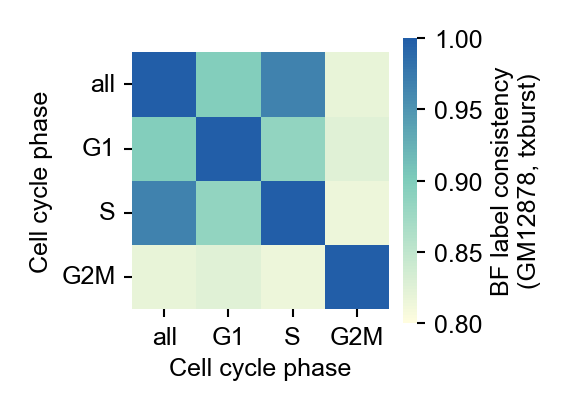

In [9]:
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]

fig, ax = plt.subplots(figsize=(5/2.54, 5/2.54))

ax = sns.heatmap(consistency_matrix[:,:,0],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0.8, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))

ticks =  [phase for phase in phases]
ax.set_xticklabels(ticks,rotation=0)
ax.set_yticklabels(ticks,rotation=0)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
ax.set_xlabel('Cell cycle phase', fontsize=6)
ax.set_ylabel('Cell cycle phase', fontsize=6)
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=6)  # 设置colorbar刻度的粗细
cbar.set_label(f'BF label consistency\n(GM12878, txburst)',fontsize=6)

plt.show()